# 13.4 USDA Food Database

## 1. Thông tin về dữ liệu

USDA Food Database (tên hiện nay là FoodData Central) là kho dữ liệu dinh dưỡng do Bộ Nông nghiệp Hoa Kỳ (USDA) duy trì. Nó tập hợp và chuẩn hóa thông tin dinh dưỡng của hàng chục nghìn thực phẩm—từ nguyên liệu thô (như thịt, rau, ngũ cốc) đến món chế biến sẵn và sản phẩm đóng gói có nhãn.

Lập trình viên Ashley Williams đã tạo ra một phiên bản JSON của cơ sở dữ liệu này, giúp chúng ta dễ dàng thao tác bằng Python.

In [1]:
import json
import pandas as pd
db = json.load(open("dataset/usda_food/database.json"))

info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)
info.head()
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   6636 non-null   object
 1   group         6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


**Nhận xét:**
- Bộ dữ liệu bao gồm 4 cột và 6636 dòng, thông tin các cột:

<!-- Dán nguyên khối này vào Markdown (HTML trong Markdown) -->
<div align="center">
  <table style="border-collapse:collapse; margin:auto;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Tên cột</th>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">description</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Tên/miêu tả của thực phẩm hoặc sản phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">group</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Nhóm thực phẩm (ngũ cốc, thịt, đồ uống…)</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">id</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Mã định danh duy nhất cho từng mục</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">manufacturer</td>
        <td style="border:1px solid #ccc; padding:10px; text-align:center;">Nhà sản xuất/thương hiệu (có thể trống)</td>
      </tr>
    </tbody>
  </table>
</div>



## 2 Kiểm tra tính toàn vẹn của dữ liệu
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [2]:
has_null = info.isnull().sum().any()
has_duplicate = info.duplicated().sum()
print(f"Giá trị Null: {has_null}")
if has_null:
    display(info[info.isnull().any(axis = 1)])
   
print(f"Giá trị duplicated: {has_duplicate}")


Giá trị Null: True


,description,group,id,manufacturer
15,"Milk, reduced fat, fluid, 2% milkfat, with add...",Dairy and Egg Products,1079,None
47,"Sour cream, reduced fat",Dairy and Egg Products,1178,None
48,"Sour cream, light",Dairy and Egg Products,1179,None
49,"Sour cream, fat free",Dairy and Egg Products,1180,None
50,"USDA Commodity, cheese, cheddar, reduced fat",Dairy and Egg Products,1182,None
...,...,...,...,...
6467,"Rolls, dinner, plain, commercially prepared (i...",Baked Products,18342,None
6468,"Rolls, dinner, whole-wheat",Baked Products,18348,None
6633,"Babyfood, juice, pear",Baby Foods,43408,None
6634,"Babyfood, dessert, banana yogurt, strained",Baby Foods,43539,None


Giá trị duplicated: 0


**Nhận xét**:

Như thông tin các cột trên, có thể thấy toàn bộ dữ liệu có tới 6636 dòng, nhưng ở cột manufacturer bị trống. Tuy nhiên trong thực tế không phải mặt hàng nào cũng có “nhà sản xuất”:

- Thực phẩm thô/không nhãn (Foundation/SR Legacy/FNDDS): ví dụ “Apple, raw” hay “Beef, raw” không thuộc một hãng cụ thể ⇒ không có manufacturer.

- Sản phẩm có nhãn (Branded Foods): ví dụ “Kellogg’s Corn Flakes” ⇒ có manufacturer: "Kellogg’s".

## 3. Phân tích mô tả

### 3.1. Xem thông tin thành phần các keys trong JSON

In [3]:
db[0].keys()
key_df = pd.DataFrame(db[0].keys())
key_df.head(7)

,0
0,id
1,description
2,tags
3,manufacturer
4,group
5,portions
6,nutrients


**Nhận xét:**

Các thành phần keys có trong JSON:

<!-- Bảng tên cột & ý nghĩa (HTML trong Markdown, căn giữa) -->
<div align="center">
  <table style="border-collapse:collapse; margin:auto;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Tên cột</th>
        <th style="border:1px solid #ccc; padding:10px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">id</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Mã định danh duy nhất của thực phẩm/sản phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">description</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Tên/miêu tả chi tiết của thực phẩm</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">tags</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Các nhãn/từ khóa liên quan </td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">manufacturer</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Nhà sản xuất/thương hiệu</td>
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">group</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Nhóm/danh mục thực phẩm 
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">portions</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Danh sách khẩu phần 
      </tr>
      <tr>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">nutrients</td>
        <td style="border:1px solid #ccc; padding:8px; text-align:center;">Danh sách chất dinh dưỡng 
      </tr>
    </tbody>
  </table>
</div>

> Các cột đều quan trọng, tuy nhiên ta chỉ quan tâm đến các cột $nutrients$ vì nó chứa thông tin cần thiết


#### 3.1.1. Khám phá Nutrients

In [4]:
db[0].keys()
db[0]["nutrients"][0]
nutrients = pd.DataFrame(db[0]["nutrients"])
nutrients.head(7)

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy
5,39.28,g,Water,Composition
6,1573.00,kJ,Energy,Energy


**Nhận xét:**

Các thành phần có trong cột $nutrients$

edit mardown this table
     


> Các cột đều quan trọng, tuy nhiên ta chỉ quan tâm đến các cột $nutrients$ vì nó chứa thông tin cần thiết


In [5]:
display(f"nan: {nutrients.isna().sum().any()}")
display(f"Số dòng bị trùng: {nutrients.duplicated().sum()}")

'nan: False'

'Số dòng bị trùng: 108'

**Nhận xét:**
- Đối với key là $nutrients$ không có missing values tuy nhiên có tới 108 dòng bị trùng, cần giảm số dòng trùng lại để tối ưu dữ liệu.

In [6]:
nutrients = nutrients.drop_duplicates()
display(f"Số dòng bị trùng: {nutrients.duplicated().sum()}")

'Số dòng bị trùng: 0'

**Nhận xét:**
- Sau khi drop các dòng bị trùng, dữ liệu có thể tối ưu nhất. Tuy nhiên tên của các cột đang bị khó 

1) Trung bình năng lượng (kcal) của từng nhóm thực phẩm là bao nhiêu?

- Tính trung bình Kcal
- Group by theo group thực phẩm
- Vẽ barchart

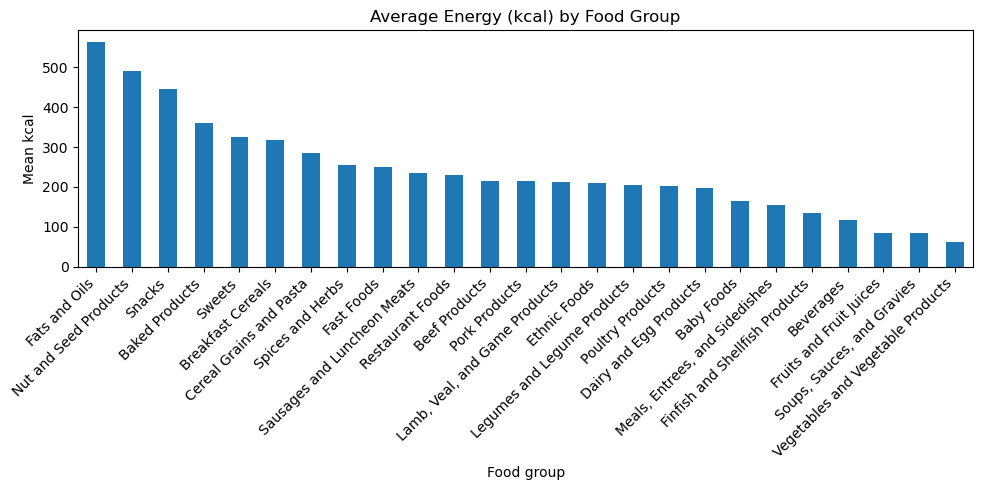

In [18]:
import pandas as pd
import numpy as np
import json, ast
import matplotlib.pyplot as plt

# Chuẩn hóa 'nutrients' về list[dict]
def _to_items(x):
    # None hoặc NaN vô hướng
    try:
        if x is None or (pd.isna(x) and not hasattr(x, "__len__")):
            return []
    except Exception:
        pass

    # numpy array -> list
    if isinstance(x, np.ndarray):
        x = x.tolist()

    # chuỗi -> parse JSON / literal
    if isinstance(x, str):
        for parser in (json.loads, ast.literal_eval):
            try:
                x = parser(x)
                break
            except Exception:
                pass

    # 1 object dict
    if isinstance(x, dict):
        return [x]

    # list/tuple -> giữ nguyên
    if isinstance(x, (list, tuple)):
        return list(x)


def extract_kcal(x):
    items = _to_items(x)
    out = pd.NA
    for it in items:
        if not isinstance(it, dict):
            continue
        desc = str(it.get("description", "")).lower()
        grp  = str(it.get("group", "")).lower()
        unit = str(it.get("units", "")).lower()
        val  = it.get("value", None)
        if ("energy" in desc) or (grp == "energy"):
            try:
                val = float(val)
            except (TypeError, ValueError):
                continue
            if unit == "kcal":
                out = val; break
            elif unit == "kj":
                out = val / 4.184; break
    return out

# --- Tính trung bình kcal theo group & vẽ barchart ---
df = info.copy()
df["kcal"] = df["nutrients"].apply(extract_kcal)  # 'nutrients' là cột chứa list/dict/chuỗi JSON

mean_kcal_by_group = (
    df.groupby("group", dropna=False)["kcal"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

plt.figure(figsize=(10,5))
mean_kcal_by_group.plot(kind="bar")
plt.ylabel("Mean kcal")
plt.xlabel("Food group")
plt.title("Average Energy (kcal) by Food Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Nhận xét:**

Nhóm năng lượng cao nhất:

- Fats and Oils đứng đầu (~550 kcal/100 g) vì mỡ = ~9 kcal/g.

- Nut & Seed Products kế tiếp (~480–500) nhiều chất béo “tốt” nên rất đậm năng lượng.

- Snacks/Baked Products/Sweets (≈ 340–460) giàu chất béo + đường/tinh bột tinh chế ⇒ mật độ năng lượng cao.

Mức trung bình (~200–280 kcal/100 g):

- Thịt/chế phẩm thịt (Beef/Pork/Poultry, Sausages…), Fast foods/Restaurant foods, Cereal/Grains/Pasta.

>Lý do: kết hợp protein + mỡ (ở thịt) hoặc tinh bột (ở ngũ cốc), ít nước hơn rau quả.

Nhóm thấp năng lượng:

- Vegetables & Vegetable Products, Soups/Sauces/Gravies, Fruit Juices/Beverages (~60–120) nhiều nước, nhiều xơ nên mật độ năng lượng thấp.

Một số điểm đáng chú ý:

- Seafood/Finfish & Shellfish thấp hơn đỏ (beef/pork) vì tỷ lệ mỡ thường thấp hơn.

- Dairy & Egg ở khoảng giữa (~190–210) do có protein + chất béo sữa.

- Breakfast cereals khá cao nếu đường/béo thêm; loại “nguyên hạt, không đường” có thể thấp hơn.

Ứng dụng thực tế:

- Muốn giảm/kiểm soát kcal: ưu tiên rau củ, canh/soup, hạn chế dầu mỡ, snack/ngọt, và đồ nướng nhiều bơ/đường.

- Muốn tăng kcal sạch: thêm hạt–nuts, dầu lành mạnh (olive, canola), bơ đậu vào khẩu phần.

- Với nuts: năng lượng cao nhưng giàu vi chất & chất béo tốt—phù hợp nếu kiểm soát khẩu phần.

2) Loại thực phẩm nào chứa protein cao nhất trong nhóm “Dairy and Egg Products”?


- lấy value có trong nutrients
- lấy group “Dairy and Egg Products” 
-> Group by 2 nhóm này và vẽ barh

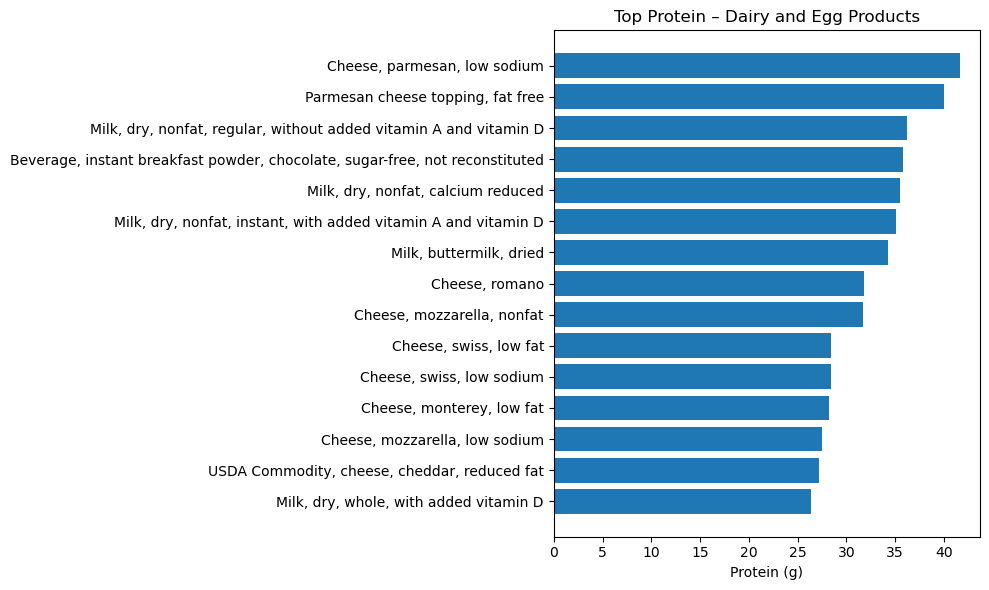

HIGHEST: Cheese, parmesan, low sodium — 41.6 g


In [23]:
import pandas as pd
import numpy as np
import json, ast
import matplotlib.pyplot as plt

# ===== 1) Tạo nutrients_df từ info['nutrients'] =====
def to_items(x):
    if x is None:
        return []
    if isinstance(x, str):
        for parser in (json.loads, ast.literal_eval):
            try:
                return parser(x)
            except Exception:
                pass
    if isinstance(x, dict):
        return [x]
    if isinstance(x, (list, tuple)):
        return list(x)
    return []

df0 = info.rename(columns={"description":"food_desc", "group":"food_group"}).copy()
df0["nutrients"] = df0["nutrients"].apply(to_items)
tmp = df0.explode("nutrients", ignore_index=True)

nut_part = tmp["nutrients"].apply(pd.Series)\
            .rename(columns={"description":"nutrient_desc", "group":"nutrient_group"})
nutrients_df = pd.concat([tmp.drop(columns=["nutrients"]), nut_part], axis=1)

# ===== 2) Lọc Protein và nhóm Dairy & Egg =====
prot = nutrients_df[
    nutrients_df["nutrient_desc"].str.casefold().eq("protein")
].copy()

# chỉ giữ đơn vị gram
prot = prot[prot["units"].str.lower().eq("g")].copy()
prot = prot.rename(columns={"value":"protein_g"})

dairy = prot[prot["food_group"] == "Dairy and Egg Products"].copy()

# gộp theo món (id + tên món), lấy max protein nếu trùng
dairy_agg = (dairy.groupby(["id","food_desc"], as_index=False)["protein_g"]
                  .max()
                  .sort_values("protein_g", ascending=False))

# ===== 3) In Top & vẽ barh =====
topN = 15
top = dairy_agg.head(topN)

plt.figure(figsize=(10, 6))
plt.barh(top["food_desc"], top["protein_g"])
plt.gca().invert_yaxis()
plt.xlabel("Protein (g)")
plt.title("Top Protein – Dairy and Egg Products")
plt.tight_layout()
plt.show()

# (tuỳ chọn) Món cao nhất:
if not dairy_agg.empty:
    best = dairy_agg.iloc[0]
    print(f"HIGHEST: {best['food_desc']} — {best['protein_g']} g")


**Nhận xét:**

Đầu bảng là các sản phẩm cô đặc/khử nước hoặc giảm/không béo:

- Cheese, parmesan (low sodium) và Parmesan cheese topping, fat free ~40–42 g protein/100 g do ít nước + ít/không béo, nên mật độ protein theo khối lượng rất cao.

- Sữa bột/đồ pha bột (Milk, dry, nonfat/regular; instant breakfast powder) cũng nằm top (~35–38 g/100 g) vì đã loại nước ⇒ protein tập trung hơn so với sữa nước.

- Phô mai ít béo/ít natri (mozzarella/swiss/monterey low fat/low sodium) ~28–32 g/100 g: khi giảm béo, tỷ lệ protein theo trọng lượng tăng.

- Sữa khô whole thấp hơn nonfat (≈27–29 g/100 g) vì có thêm chất béo, làm loãng tỉ lệ protein theo khối lượng.

>Hàm ý thực tế: nếu mục tiêu tăng lượng protein/100 g thực phẩm, ưu tiên phô mai cứng (đặc biệt parmesan), sữa bột không béo và phô mai ít béo. Tuy nhiên cần cân nhắc natri, chất béo bão hòa, và khẩu phần thực tế (100 g parmesan là nhiều hơn khẩu phần ăn thường dùng).

3) Các nhóm thực phẩm nào phổ biến trong dataset?

In [ ]:
pd.value_counts(info["group"])[:10]

C:\Users\luong\AppData\Local\Temp\ipykernel_16512\3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Name: count, dtype: int64

C:\Users\luong\AppData\Local\Temp\ipykernel_2648\3676752110.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  group_counts = pd.value_counts(info["group"])[:]


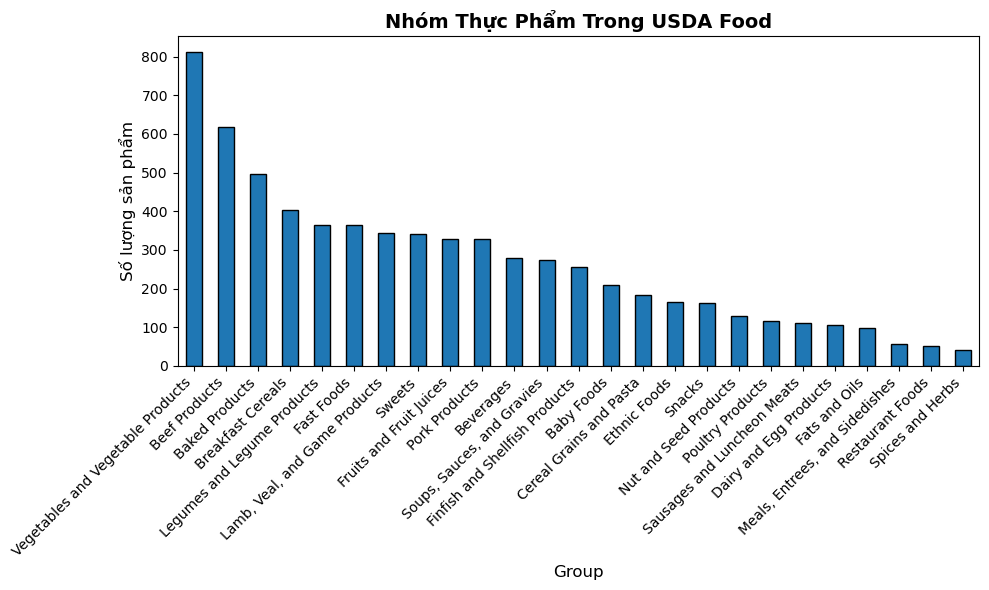

In [17]:
import matplotlib.pyplot as plt
group_counts = pd.value_counts(info["group"])[:]

plt.figure(figsize=(10,6))
group_counts.plot(kind='bar', edgecolor='black')

plt.title("Nhóm Thực Phẩm Trong USDA Food", fontsize=14, weight='bold')
plt.xlabel("Group", fontsize=12)
plt.ylabel("Số lượng sản phẩm", fontsize=12)
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('top_10_groups.png', dpi=300, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Trong toàn bộ nhóm sản phẩm nổi bật thì các loại rau củ (~800), sản phẩm từ thịt bò (~600) và sản phẩm đồ nướng (500) là các nhóm có độ phổ biến cũng như số lượng cao nhất trong toàn bộ nhóm sản phẩm.



## 4. Phân tích so sánh

1) So sánh hàm lượng protein và lipid (chất béo) giữa nhóm “Meat” và “Dairy”?

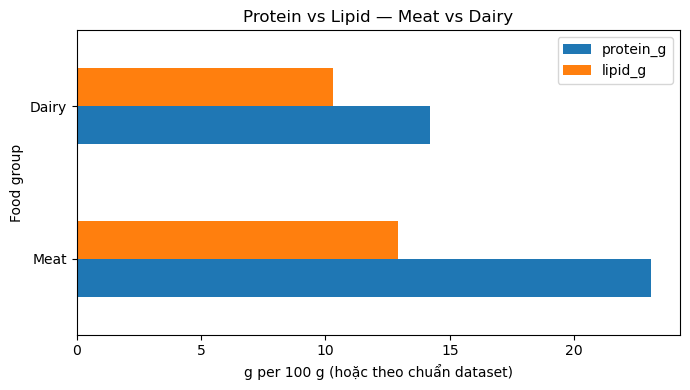

In [25]:
import pandas as pd
import numpy as np
import json, ast
import matplotlib.pyplot as plt

# ---------- 0) Chuẩn bị nutrients_df nếu chưa có ----------
def to_items(x):
    if x is None: return []
    if isinstance(x, str):
        for parser in (json.loads, ast.literal_eval):
            try: return parser(x)
            except Exception: pass
    if isinstance(x, dict): return [x]
    if isinstance(x, (list, tuple)): return list(x)
    return []

if "nutrients_df" not in globals():
    df0 = info.rename(columns={"description":"food_desc", "group":"food_group"}).copy()
    df0["nutrients"] = df0["nutrients"].apply(to_items)
    tmp = df0.explode("nutrients", ignore_index=True)
    nut_part = tmp["nutrients"].apply(pd.Series)\
                 .rename(columns={"description":"nutrient_desc", "group":"nutrient_group"})
    nutrients_df = pd.concat([tmp.drop(columns=["nutrients"]), nut_part], axis=1)

# ---------- 1) Lọc Protein & Lipid (g) ----------
nut = nutrients_df.copy()
nut["nutrient_desc_l"] = nut["nutrient_desc"].str.casefold()
nut["units_l"] = nut["units"].str.lower()

is_protein = nut["nutrient_desc_l"].eq("protein") & nut["units_l"].eq("g")
# “Total lipid (fat)” đôi khi viết khác nhau -> dùng contains
is_lipid   = nut["nutrient_desc_l"].str.contains("total lipid") & nut["units_l"].eq("g")

prot = (nut.loc[is_protein, ["id","food_desc","food_group","value"]]
          .rename(columns={"value":"protein_g"}))
lipid = (nut.loc[is_lipid,   ["id","food_desc","food_group","value"]]
          .rename(columns={"value":"lipid_g"}))

# Gộp để có 1 dòng/food: lấy max nếu có trùng
prot_agg  = prot.groupby(["id","food_desc","food_group"], as_index=False)["protein_g"].max()
lipid_agg = lipid.groupby(["id","food_desc","food_group"], as_index=False)["lipid_g"].max()

df = prot_agg.merge(lipid_agg, on=["id","food_desc","food_group"], how="outer")

# ---------- 2) Quy về nhóm rộng: 'Meat' vs 'Dairy' ----------
def broad_group(g):
    g_l = str(g).casefold()
    if any(k in g_l for k in [
        "beef", "pork", "lamb", "veal", "game", "sausage", "meat", "poultry"
    ]):
        return "Meat"
    if "dairy" in g_l or "egg" in g_l:
        return "Dairy"
    return None

df["broad_group"] = df["food_group"].map(broad_group)
df2 = df[df["broad_group"].isin(["Meat","Dairy"])].copy()

# ---------- 3) Tính trung bình theo nhóm ----------
summary = (df2.groupby("broad_group")[["protein_g","lipid_g"]]
             .mean()
             .round(2)
             .reindex(["Meat","Dairy"]))  # cố định thứ tự

# ---------- 4) Vẽ barh so sánh ----------
ax = summary.plot(kind="barh", figsize=(7,4))
ax.set_xlabel("g per 100 g (hoặc theo chuẩn dataset)")
ax.set_ylabel("Food group")
ax.set_title("Protein vs Lipid — Meat vs Dairy")
plt.tight_layout()
plt.show()


**Nhận xét:**

Protein trung bình:

- Meat cao hơn rõ rệt (~23 g) so với Dairy (~14–15 g). Thịt nhìn chung giàu đạm hơn sữa/phô mai tính theo 100 g.

Lipid (chất béo) trung bình:

- Meat ≈ 13 g, Dairy ≈ 10 g chênh lệch không quá lớn, nhưng thịt vẫn nhỉnh hơn.

Tỷ lệ Đạm/Béo (protein_g / lipid_g):

- Meat ≈ 23/13 ≈ 1.77

- Dairy ≈ 14/10 ≈ 1.4

⇒ Meat có đậm độ đạm tốt hơn (nhiều g protein trên mỗi g mỡ), phù hợp mục tiêu tăng đạm mà không tăng mỡ quá nhiều.

Hàm ý dinh dưỡng:

- Nếu ưu tiên tăng protein: thịt nạc (lean cuts, gia cầm bỏ da) có lợi thế.

- Dairy vẫn hữu ích (dễ dùng, giàu canxi), nhưng chọn loại ít béo (non-/low-fat) sẽ cải thiện tỷ lệ đạm/béo.


2) Tỷ lệ Energy-to-Protein khác biệt thế nào giữa nhóm “Grains” và “Vegetables”?
→ dùng pivot_table(values='value', index='group', columns='description').

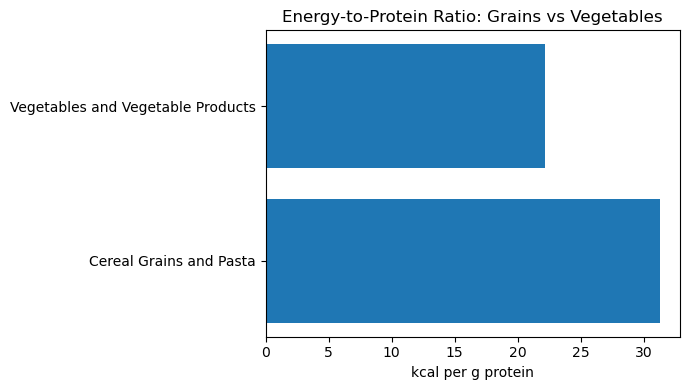

In [28]:
import pandas as pd
import numpy as np
import json, ast
import matplotlib.pyplot as plt

# --- 1) Explode nutrients -> nutrients_df ---
def to_items(x):
    if x is None: return []
    if isinstance(x, str):
        for parser in (json.loads, ast.literal_eval):
            try: return parser(x)
            except Exception: pass
    if isinstance(x, dict): return [x]
    if isinstance(x, (list, tuple)): return list(x)
    return []

df0 = info.rename(columns={"description":"food_desc", "group":"group"}).copy()
df0["nutrients"] = df0["nutrients"].apply(to_items)
tmp = df0.explode("nutrients", ignore_index=True)

nut = tmp["nutrients"].apply(pd.Series)\
        .rename(columns={"description":"description", "group":"nutrient_group"})
nutrients_df = pd.concat([tmp.drop(columns=["nutrients"]), nut], axis=1)

# --- 2) Chuẩn hóa: lấy Energy (quy về kcal) & Protein (g), để cột 'description' là 'Energy' / 'Protein' ---
x = nutrients_df.copy()
x["desc_l"]  = x["description"].str.casefold()
x["units_l"] = x["units"].str.lower()

# Energy -> kcal
mask_energy = (x["desc_l"].eq("energy")) | (x["nutrient_group"].str.casefold() == "energy")
energy = x.loc[mask_energy, ["group", "value", "units"]].copy()
energy["value"] = np.where(energy["units"].str.lower().eq("kj"),
                           energy["value"] / 4.184,  # kJ -> kcal
                           energy["value"])
energy["description"] = "Energy"
energy = energy[["group", "description", "value"]]

# Protein -> g
mask_prot = x["desc_l"].eq("protein") & x["units_l"].eq("g")
protein = x.loc[mask_prot, ["group", "value"]].copy()
protein["description"] = "Protein"
protein = protein[["group", "description", "value"]]

# Gộp lại để pivot
tidy = pd.concat([energy, protein], ignore_index=True)

# --- 3) Pivot: mean theo group (cột 'description' = Energy / Protein) ---
pt = tidy.pivot_table(values="value", index="group", columns="description", aggfunc="mean")

# --- 4) Lọc 2 nhóm cần so sánh (tên có thể là 'Cereal Grains and Pasta' và 'Vegetables and Vegetable Products') ---
sel = pt[(pt.index.str.contains("grain", case=False)) | (pt.index.str.contains("vegetable", case=False))].copy()

# Tính tỷ lệ Energy-to-Protein
sel["E2P"] = sel["Energy"] / sel["Protein"]

# --- 5) Vẽ barh cho E2P ---
plt.figure(figsize=(7,4))
plt.barh(sel.index, sel["E2P"])
plt.xlabel("kcal per g protein")
plt.title("Energy-to-Protein Ratio: Grains vs Vegetables")
plt.tight_layout()
plt.show()


**Nhận xét:**

Cereal Grains and Pasta ~ 31 kcal/g > Vegetables and Vegetable Products ~ 22 kcal/g.

⇒ Cùng 1 g protein, ngũ cốc phải “trả” nhiều kcal hơn so với rau củ. Nói cách khác, rau củ “hiệu quả protein” hơn về mặt năng lượng.

Lý do khả dĩ:

- Grains giàu carb tinh bột, tỉ lệ protein theo trọng lượng thấp 

- Vegetables nhiều nước và xơ (năng lượng thấp), dù protein tuyệt đối cũng không cao, nên E2P vẫn thấp hơn grains.

Hàm ý thực tế:

- Nếu muốn tối ưu protein/kcal (siết năng lượng), ưu tiên rau củ làm nền, bổ sung nguồn protein nạc khác; hạn chế phụ thuộc protein từ ngũ cốc.

- Nếu cần năng lượng rẻ cho hoạt động bền bỉ, ngũ cốc vẫn là lựa chọn tốt, nhưng không hiệu quả nếu mục tiêu chính là tăng protein.

## 5. Phân tích tương quan

1) Có mối tương quan nào giữa năng lượng (Energy) và hàm lượng chất béo (Fat)?
→ ndata.pivot(...) → tính corr().

In [27]:
import pandas as pd
import numpy as np
import json, ast

# --- 1) Explode 'nutrients' thành dạng dài (nếu bạn chỉ có DataFrame 'info') ---
def to_items(x):
    if x is None: return []
    if isinstance(x, str):
        for parser in (json.loads, ast.literal_eval):
            try: return parser(x)
            except Exception: pass
    if isinstance(x, dict): return [x]
    if isinstance(x, (list, tuple)): return list(x)
    return []

df0 = info.rename(columns={"description":"food_desc", "group":"food_group"}).copy()
df0["nutrients"] = df0["nutrients"].apply(to_items)
tmp = df0.explode("nutrients", ignore_index=True)

nut = tmp["nutrients"].apply(pd.Series)\
        .rename(columns={"description":"nutrient_desc", "group":"nutrient_group"})
ndf = pd.concat([tmp.drop(columns=["nutrients"]), nut], axis=1)

# --- 2) Chuẩn hoá Energy (kJ -> kcal) & chọn Total lipid (fat) (g) ---
x = ndf.copy()
x["desc_l"]  = x["nutrient_desc"].str.casefold()
x["units_l"] = x["units"].str.lower()

# Energy -> kcal
is_energy = (x["desc_l"].eq("energy")) | (x["nutrient_group"].str.casefold() == "energy")
x.loc[is_energy, "value"] = np.where(
    x.loc[is_energy, "units_l"].eq("kj"),
    x.loc[is_energy, "value"] / 4.184,   # đổi kJ -> kcal
    x.loc[is_energy, "value"]
)
x.loc[is_energy, "nutrient_desc"] = "Energy"
x.loc[is_energy, "units"] = "kcal"

# Total lipid (fat) -> g
is_fat = x["desc_l"].str.startswith("total lipid") & x["units_l"].eq("g")
x.loc[is_fat, "nutrient_desc"] = "Total lipid (fat)"

# Giữ chỉ 2 chất cần thiết
keep = is_energy | is_fat
tidy = x.loc[keep, ["id", "nutrient_desc", "value"]].copy()

# --- 3) Pivot: mỗi thực phẩm 1 hàng, 2 cột: Energy & Total lipid (fat) ---
# Nếu 1 thực phẩm có nhiều dòng cho cùng nutrient, dùng max/mean đều được; ở đây dùng max.
ndata = tidy.pivot_table(values="value", index="id", columns="nutrient_desc", aggfunc="max")

# Đảm bảo đủ 2 cột
cols_needed = ["Energy", "Total lipid (fat)"]
ndata = ndata.reindex(columns=cols_needed)
ndata = ndata.dropna(subset=cols_needed)

# (Tuỳ chọn) đổi tên cột cho gọn
ndata = ndata.rename(columns={"Total lipid (fat)": "Fat"})

# --- 4) Tính tương quan (Pearson) ---
corr_matrix = ndata[["Energy", "Fat"]].corr(method="pearson")
print("Correlation matrix (Energy vs Fat):")
print(corr_matrix)

# Hệ số tương quan đơn (tiện in ra)
r = corr_matrix.loc["Energy", "Fat"]
print(f"\nPearson r (Energy ~ Fat) = {r:.3f}")


Correlation matrix (Energy vs Fat):
nutrient_desc    Energy       Fat
nutrient_desc                    
Energy         1.000000  0.767979
Fat            0.767979  1.000000

Pearson r (Energy ~ Fat) = 0.768


**Nhận xét:**

r (Energy ~ Fat) = 0.768 

⇒ tương quan dương mạnh: thực phẩm có chất béo cao thường có năng lượng (kcal) cao. Điều này phù hợp sinh lý học vì 1 g fat ≈ 9 kcal, nên fat là nguồn năng lượng đậm đặc nhất.

Không phải hoàn hảo (r < 1) vì năng lượng còn đến từ carb (~4 kcal/g) và protein (~4 kcal/g); ngoài ra, độ ẩm/nước làm loãng mật độ năng lượng.

Nguy cơ ngoại lệ/điểm ảnh hưởng: dầu/mỡ thuần sẽ kéo r lên rất mạnh; các thực phẩm giàu nước (canh, rau) kéo r xuống.

Diễn giải thực tế:

- Muốn giảm kcal → kiểm soát chất béo là đòn bẩy lớn.

- Muốn tăng cân/đủ năng lượng → thêm chất béo là cách nhanh tăng kcal, nhưng cần chọn chất béo lành mạnh và kiểm soát khẩu phần.

# KẾT THÚC